In [20]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
# Dataset paths
train_dir = r"C:\Users\hanaa\Downloads\DataSet (4)\training"
test_dir = r"C:\Users\hanaa\Downloads\DataSet (4)\training"
print("Training directory:", train_dir)
print("Testing directory:", test_dir)

Training directory: C:\Users\hanaa\Downloads\DataSet (4)\training
Testing directory: C:\Users\hanaa\Downloads\DataSet (4)\training


In [30]:
#resizing and normalization
# Resizing: images are scaled to the same size (128x128) so the model can process them
# Normalization: pixel values are divided by 255 to convert range from 0–255 to 0–1
# Batch size is used to speed up training and reduce memory usage
# Pixel values are scaled (0–1) to make training more stable and faster
# Data is loaded from folders where each folder represents a class
# Binary mode is used because the task has only two classes
# Test data is not shuffled so results can be matched correctly with labels
# Image size and batch settings
img_height = 128   # resize height
img_width = 128    # resize width
batch_size = 32    # images per batch

# Generators to preprocess images (normalize pixels 0–1)
train_datagen = ImageDataGenerator(rescale=1.0/255)
test_datagen = ImageDataGenerator(rescale=1.0/255)

# Load training images from directory
train_data = train_datagen.flow_from_directory(
    train_dir,                          # training folder path
    target_size=(img_height, img_width),# resize images
    batch_size=batch_size,              # batch size
    class_mode="binary"                 # 2 classes (0 or 1)
)

# Load testing images from directory
test_data = test_datagen.flow_from_directory(
    test_dir,                           # testing folder path
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode="binary",
    shuffle=False                       # keep order for evaluation
)

Found 200 images belonging to 2 classes.
Found 200 images belonging to 2 classes.


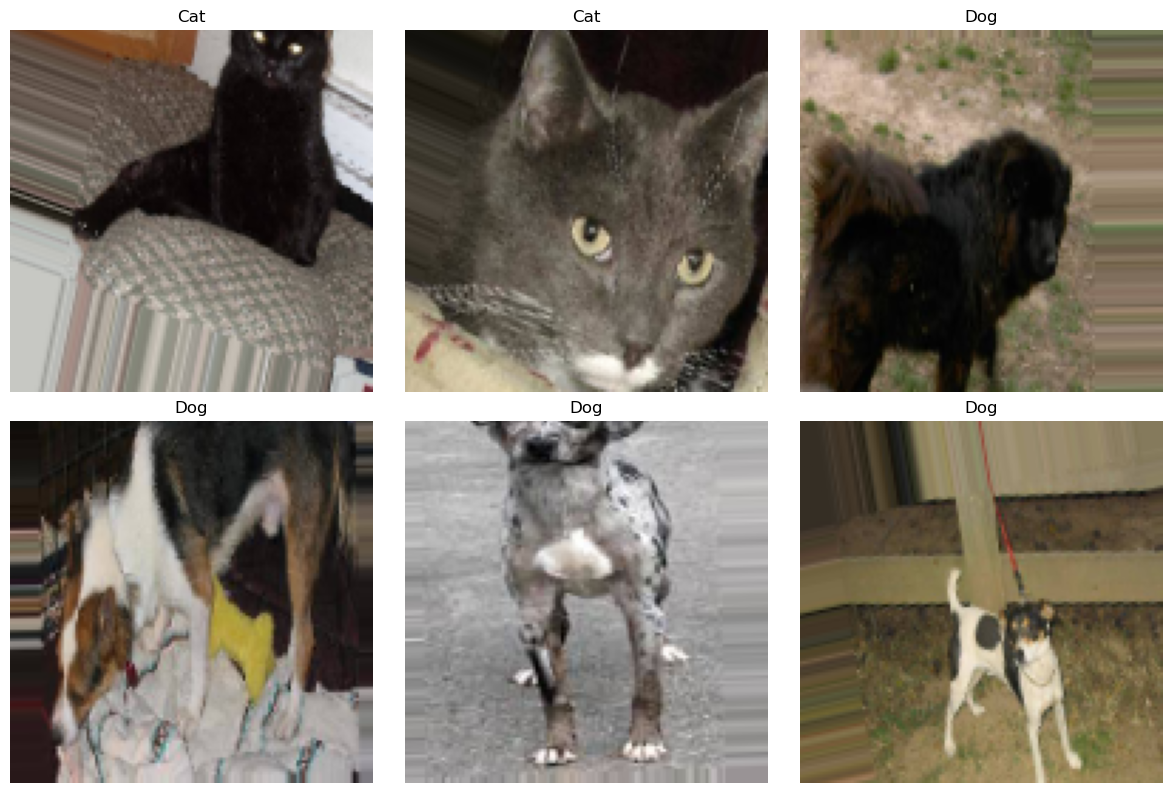

In [31]:
#dipslay a batch of training images

# Get one batch of training data
images, labels = next(train_data)
# Display first 6 images
plt.figure(figsize=(12, 8))
for i in range(6):
    plt.subplot(2, 3, i + 1)
    plt.imshow(images[i])
    plt.title("Dog" if labels[i] == 1 else "Cat")
    plt.axis("off")
plt.tight_layout()
plt.show()

In [21]:
# build cnn model

# Build the CNN model
model = Sequential([
    Conv2D(32, (3, 3), activation="relu", input_shape=(img_height, img_width, 3)),  # 32 filters, detect features
    MaxPooling2D(pool_size=(2, 2)),  # reduce spatial size

    Conv2D(64, (3, 3), activation="relu"),  # deeper feature extraction
    MaxPooling2D(pool_size=(2, 2)),  # further downsampling

    Flatten(),  # convert 2D feature maps to 1D vector

    Dense(128, activation="relu"),  # fully connected layer
    Dense(1, activation="sigmoid")  # output layer (binary classification)
])

# Display model summary
model.summary()

C:\Users\hanaa\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)                    │ (None, 126, 126, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 63, 63, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 61, 61, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 30, 30, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 57600)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 128)                 │       7,372,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 7,392,449 (28.20 MB)

 Trainable params: 7,392,449 (28.20 MB)

 Non-trainable params: 0 (0.00 B)

In [32]:
# compile and train the cnn model

# Compile the model (set how it learns)
model.compile(
    optimizer="adam",              # optimizer to update weights
    loss="binary_crossentropy",    # loss function for binary classification
    metrics=["accuracy"]           # measure performance
)

# Train the model
history = model.fit(
    train_data,                    # training dataset
    epochs=10,                     # number of times model sees all data
    validation_data=test_data      # evaluate on unseen data during training
)

Epoch 1/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 15s 1s/step - accuracy: 0.5300 - loss: 0.7494 - val_accuracy: 0.7500 - val_loss: 0.4258
Epoch 2/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 7s 971ms/step - accuracy: 0.6600 - loss: 0.6398 - val_accuracy: 0.8050 - val_loss: 0.4895
Epoch 3/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 7s 912ms/step - accuracy: 0.6050 - loss: 0.6587 - val_accuracy: 0.7850 - val_loss: 0.4737
Epoch 4/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 7s 961ms/step - accuracy: 0.5750 - loss: 0.6460 - val_accuracy: 0.8550 - val_loss: 0.5032
Epoch 5/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 7s 904ms/step - accuracy: 0.5450 - loss: 0.7150 - val_accuracy: 0.8400 - val_loss: 0.5131
Epoch 6/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step - accuracy: 0.6500 - loss: 0.6446 - val_accuracy: 0.7700 - val_loss: 0.5605
Epoch 7/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step - accuracy: 0.6250 - loss: 0.6614 - val_accuracy: 0.7900 - val_loss: 0.5400
Epoch 8/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 8s 944ms/step - accuracy: 0.5850 - loss: 0.6592 - val_accuracy: 0.9100 - val_loss: 0.4613

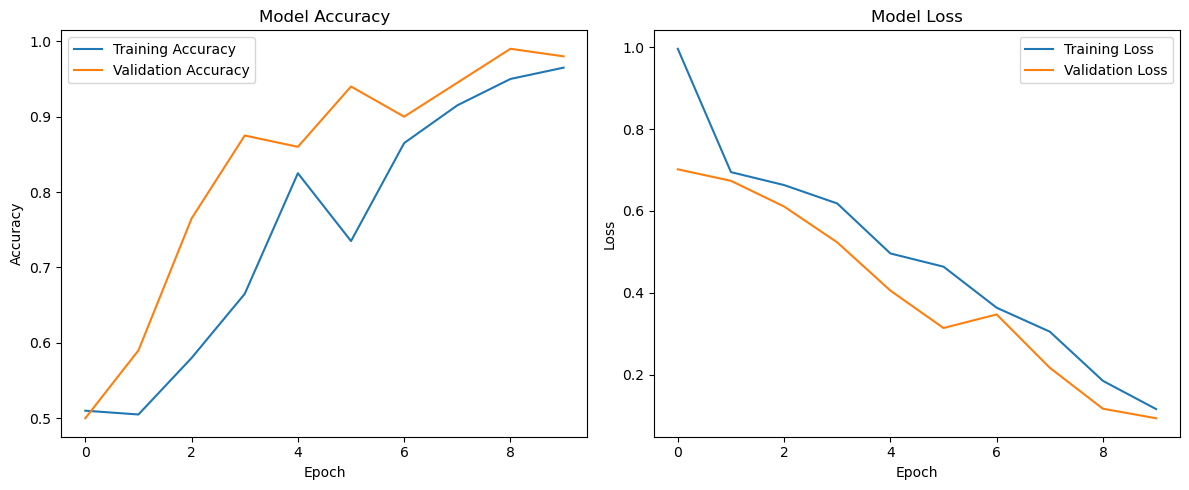

In [13]:
#pot training and validation performance

# Plot accuracy
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
# Plot loss
plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.show()

In [36]:
#evaluate model on test data

from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
# Reset test generator (important)
test_data.reset()
# Get predictions on entire test set
predictions = model.predict(test_data)
predicted_classes = (predictions > 0.5).astype(int).reshape(-1)
# True labels
true_classes = test_data.classes
# Confusion matrix
cm = confusion_matrix(true_classes, predicted_classes)
print("Confusion Matrix:\n", cm)
# Classification report (precision, recall, F1-score)
print("\nClassification Report:\n")
print(classification_report(true_classes, predicted_classes,
target_names=["Cat", "Dog"]))
 

7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 204ms/step
Confusion Matrix:
 [[86 14]
 [15 85]]

Classification Report:

              precision    recall  f1-score   support

         Cat       0.85      0.86      0.86       100
         Dog       0.86      0.85      0.85       100

    accuracy                           0.85       200
   macro avg       0.86      0.85      0.85       200
weighted avg       0.86      0.85      0.85       200



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 204ms/step


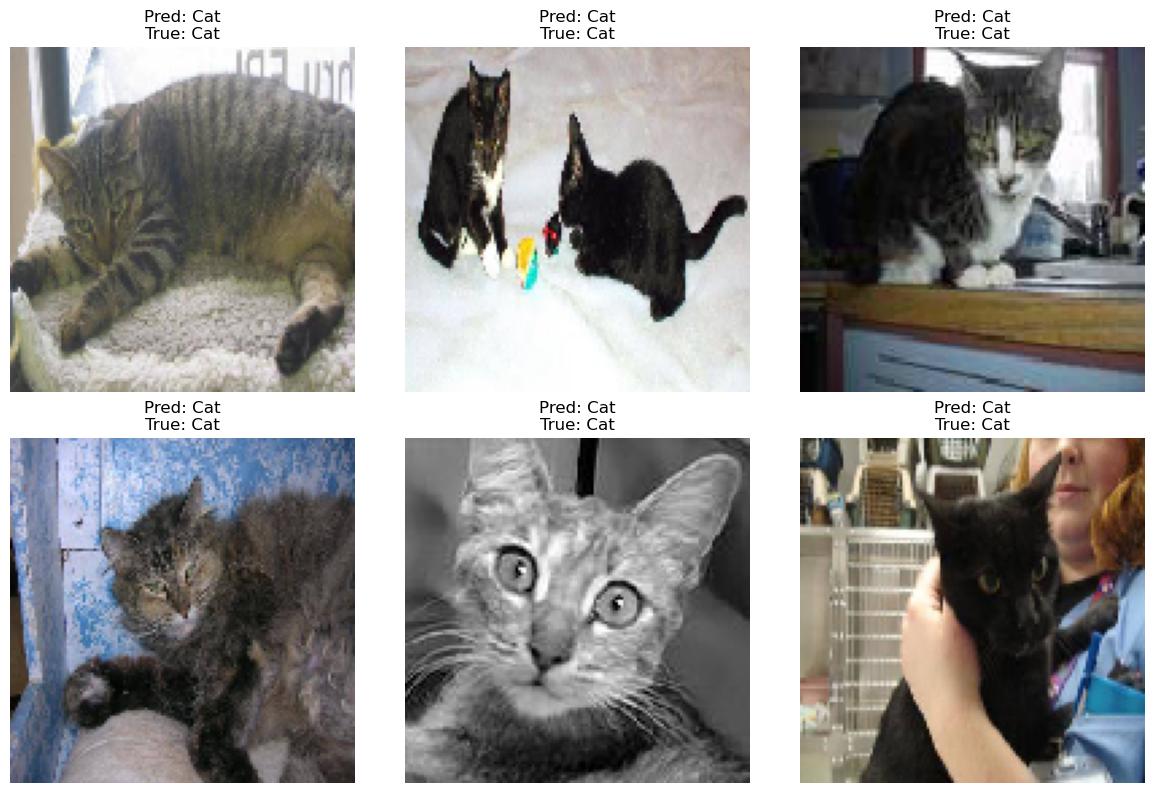

In [37]:
# Reset test generator (important)
test_data.reset()

# Get one batch of test data
test_images, test_labels = next(test_data)

# Make predictions
predictions = model.predict(test_images)

# Display results
plt.figure(figsize=(12, 8))

for i in range(6):
    plt.subplot(2, 3, i + 1)
    plt.imshow(test_images[i])

    # Convert prediction to label
    pred_label = "Dog" if predictions[i] > 0.5 else "Cat"
    true_label = "Dog" if test_labels[i] == 1 else "Cat"

    plt.title(f"Pred: {pred_label}\nTrue: {true_label}")
    plt.axis("off")

plt.tight_layout()
plt.show()